In [5]:
import os
import json
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import openai
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

 Starting LLM Zero-Shot Triage Prediction for 750 samples (25% Test Set)...
Processed 50/750 samples...
Processed 100/750 samples...
Processed 150/750 samples...
Processed 200/750 samples...
Processed 250/750 samples...
Processed 300/750 samples...
Processed 350/750 samples...
Processed 400/750 samples...
Processed 450/750 samples...
Processed 500/750 samples...
Processed 550/750 samples...
Processed 600/750 samples...
Processed 650/750 samples...
Processed 700/750 samples...
Processed 750/750 samples...

🔥 Final GPT-4o-mini Zero-Shot Classification Report:
              precision    recall  f1-score   support

     Level 0       0.99      0.97      0.98       179
     Level 1       0.97      0.96      0.96       189
     Level 2       0.97      0.99      0.98       185
     Level 3       0.99      1.00      0.99       197

    accuracy                           0.98       750
   macro avg       0.98      0.98      0.98       750
weighted avg       0.98      0.98      0.98       750



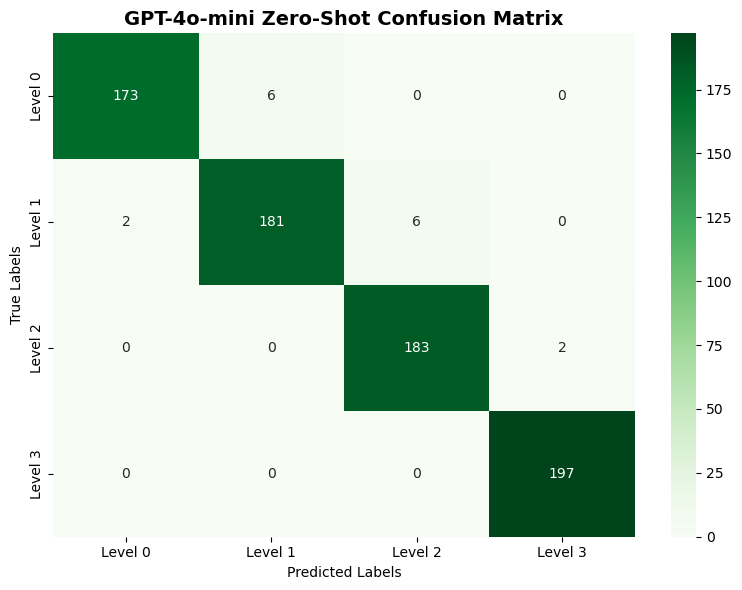

In [9]:
load_dotenv()
client = openai.OpenAI(api_key=os.getenv('OPENAI_API_KEY'))

df = pd.read_csv("manchester_postpartum_triage_v1.csv")

X_train_temp, X_temp, y_train_temp, y_temp = train_test_split(
    df['patient_message'].astype(str).tolist(), 
    df['triage_level'].astype(int).tolist(), 
    test_size=0.40, 
    random_state=42, 
    stratify=df['triage_level'].astype(int).tolist()
)

X_val_dummy, X_test, y_val_dummy, y_test = train_test_split(
    X_temp, y_temp, test_size=0.625, random_state=42, stratify=y_temp
)

test_df = pd.DataFrame({
    'patient_message': X_test,  
    'true_label': y_test        
})
# =========================================================================

gpt_preds = []
total_samples = len(test_df)

print(f" Starting LLM Zero-Shot Triage Prediction for {total_samples} samples (25% Test Set)...")

# 2. A loop that runs on the Test Set and sends to GPT
for idx, row in test_df.iterrows():
    message = row['patient_message']
    
    system_prompt = "You are an expert medical triage assistant. You strictly follow the Manchester Triage System. Return ONLY a JSON object."
    
    user_prompt = f"""
    Analyze the following postpartum patient/caregiver message and classify it into exactly one Manchester Triage Level (0, 1, 2, or 3).
    
    [CRITERIA PROTOCOL]:
    - 0 (Routine): Standard post-op symptoms (mild soreness, light discharge, tired but stable). No danger signs.
    - 1 (Low Urgency): Mild complications (mild localized redness, slight constipation, minor pain managed by pills).
    - 2 (Medium Urgency): Significant symptoms needing evaluation within hours (widening redness, foul discharge, new fever under 38.5°C, inability to urinate).
    - 3 (High Urgency): Immediate life-threatening emergency (massive bleeding, sudden shortness of breath, stabbing chest pain, fever over 39°C, swollen/hot calf).
    
    [PATIENT MESSAGE]:
    "{message}"
    
    Return a JSON object with exactly one key: "predicted_level" containing an integer (0, 1, 2, or 3).
    """
    
    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            temperature=0.0,  
            response_format={"type": "json_object"},
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ]
        )
        
        res = json.loads(response.choices[0].message.content.strip())
        pred = int(res["predicted_level"])
        gpt_preds.append(pred)
        
    except Exception as e:
        print(f"Error at index {idx}: {e}")
        gpt_preds.append(0)  
        
    # Print progress
    if (idx + 1) % 50 == 0:
        print(f"Processed {idx + 1}/{total_samples} samples...")

# 3. Adding the predictions to the table
test_df['gpt_pred'] = gpt_preds

# 4. Print the final report for comparison
print("\n🔥 Final GPT-4o-mini Zero-Shot Classification Report:")
print(classification_report(test_df['true_label'], test_df['gpt_pred'], target_names=["Level 0", "Level 1", "Level 2", "Level 3"]))

# 5. Drawing an error matrix for GPT
cm_gpt = confusion_matrix(test_df['true_label'], test_df['gpt_pred'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm_gpt, annot=True, fmt='d', cmap='Greens', 
            xticklabels=["Level 0", "Level 1", "Level 2", "Level 3"], 
            yticklabels=["Level 0", "Level 1", "Level 2", "Level 3"])
plt.title("GPT-4o-mini Zero-Shot Confusion Matrix", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.savefig("gpt_confusion_matrix.png", dpi=300)
plt.show()